In [54]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
warnings.filterwarnings("ignore")
begDate    = "20200130"
endData    = "20201123"
sampleDate = "20210421"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
nodatelist = pbd.get_range("20201123", "20210421")
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = 'timedelay_verystrict2'# path.split('.')[0].split('/')[-1]

In [33]:
# root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
# sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
# sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
# sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
# sample_1min_df.sort_index().head(200)

In [55]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

  0%|          | 0/199 [00:00<?, ?it/s][Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:  1.1min
100%|██████████| 199/199 [01:04<00:00,  3.06it/s]
[Parallel(n_jobs=100)]: Done   2 tasks      | elapsed:  1.1min
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:  1.1min remaining: 10.1min
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:  1.2min remaining:  4.7min
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:  1.2min remaining:  2.8min
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:  1.2min remaining:  1.8min
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:  1.2min remaining:  1.2min
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:  1.2min remaining:   49.4s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:  1.3min remaining:   32.0s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:  1.3min remaining:   18.7s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elap

In [7]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [8]:
# # sampleDate = "20240409"
# root_dir = '/data/nfs0/chinaEquityData/panel/'
# def loadingfeaturetbl(sampleDate, alpha_name):
#     # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
#     sample_1min_df = panel.sdiv2df(
#         panel.read(f"{root_dir}5min/5min-{sampleDate}.sdiv").sel(V = slice("midPriceLastValid", "close.avg"))
#     )
#     return sample_1min_df


# Process_1min_df_2 = Parallel(n_jobs=100, verbose=10)(
#     delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
# )
# feature_1min_df_2 = pd.concat(Process_1min_df_2, ignore_index=True)
# feature_1min_df_2 = feature_1min_df_2.set_index(['sid','date','time'])

In [56]:
# label_df = pd.read_feather("/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/label_df_2020_202011.feather")


feature_1min_df['Mean_passiveDelay_B_divadd'] = (feature_1min_df['Mean_passiveBuyDelay'] ) / (feature_1min_df['Mean_passiveBuyDelay'] + feature_1min_df['Mean_passiveSellDelay'] ) 
feature_1min_df['Mean_passiveDelay_S_divadd'] = (feature_1min_df['Mean_passiveSellDelay'] ) / (feature_1min_df['Mean_passiveBuyDelay'] + feature_1min_df['Mean_passiveSellDelay'] ) 
feature_1min_df['Mean_passiveDelay_SB_ratio'] = (feature_1min_df['Mean_passiveSellDelay'] - feature_1min_df['Mean_passiveBuyDelay'] ) / (feature_1min_df['Mean_passiveSellDelay'] + feature_1min_df['Mean_passiveBuyDelay'] ) 

feature_1min_df['Std_passiveDelay_B_divadd'] = (feature_1min_df['Std_passiveBuyDelay'] ) / (feature_1min_df['Std_passiveBuyDelay'] + feature_1min_df['Std_passiveSellDelay'] ) 
feature_1min_df['Std_passiveDelay_S_divadd'] = (feature_1min_df['Std_passiveSellDelay'] ) / (feature_1min_df['Std_passiveBuyDelay'] + feature_1min_df['Std_passiveSellDelay'] ) 
feature_1min_df['Std_passiveDelay_SB_ratiostd'] = (feature_1min_df['Std_passiveSellDelay'] - feature_1min_df['Std_passiveBuyDelay'] ) / (feature_1min_df['Std_passiveSellDelay'] + feature_1min_df['Std_passiveBuyDelay'] ) 
feature_1min_df['Std_passiveDelay_SB_ratioavg'] = (feature_1min_df['Std_passiveSellDelay'] - feature_1min_df['Std_passiveBuyDelay'] ) / (feature_1min_df['Mean_passiveSellDelay'] + feature_1min_df['Mean_passiveBuyDelay'] ) 


feature_1min_df['Mean_passiveRatio_B_divadd'] = (feature_1min_df['Mean_passiveBuyRatio'] ) / (feature_1min_df['Mean_passiveBuyRatio'] + feature_1min_df['Mean_passiveSellRatio'] ) 
feature_1min_df['Mean_passiveRatio_S_divadd'] = (feature_1min_df['Mean_passiveSellRatio'] ) / (feature_1min_df['Mean_passiveBuyRatio'] + feature_1min_df['Mean_passiveSellRatio'] ) 
feature_1min_df['Mean_passiveRatio_SB_ratio'] = (feature_1min_df['Mean_passiveSellRatio'] - feature_1min_df['Mean_passiveBuyRatio'] ) / (feature_1min_df['Mean_passiveSellRatio'] + feature_1min_df['Mean_passiveBuyRatio'] ) 

feature_1min_df['Std_passiveRatio_B_divadd'] = (feature_1min_df['Std_passiveBuyRatio'] ) / (feature_1min_df['Std_passiveBuyRatio'] + feature_1min_df['Std_passiveSellRatio'] ) 
feature_1min_df['Std_passiveRatio_S_divadd'] = (feature_1min_df['Std_passiveSellRatio'] ) / (feature_1min_df['Std_passiveBuyRatio'] + feature_1min_df['Std_passiveSellRatio'] ) 
feature_1min_df['Std_passiveRatio_SB_ratiostd'] = (feature_1min_df['Std_passiveSellRatio'] - feature_1min_df['Std_passiveBuyRatio'] ) / (feature_1min_df['Std_passiveSellRatio'] + feature_1min_df['Std_passiveBuyRatio'] ) 
feature_1min_df['Std_passiveRatio_SB_ratioavg'] = (feature_1min_df['Std_passiveSellRatio'] - feature_1min_df['Std_passiveBuyRatio'] ) / (feature_1min_df['Mean_passiveSellRatio'] + feature_1min_df['Mean_passiveBuyRatio'] ) 


feature_1min_df['float64_len_passiveDelay_B_divadd'] = (feature_1min_df['float64_len_passiveBuyDelay'] ) / (feature_1min_df['float64_len_passiveBuyDelay'] + feature_1min_df['float64_len_passiveSellDelay'] ) 
feature_1min_df['float64_len_passiveDelay_S_divadd'] = (feature_1min_df['float64_len_passiveSellDelay'] ) / (feature_1min_df['float64_len_passiveBuyDelay'] + feature_1min_df['float64_len_passiveSellDelay'] ) 
feature_1min_df['float64_len_passiveDelay_SB_ratio'] = (feature_1min_df['float64_len_passiveSellDelay'] - feature_1min_df['float64_len_passiveBuyDelay'] ) / (feature_1min_df['float64_len_passiveSellDelay'] + feature_1min_df['float64_len_passiveBuyDelay'] ) 

feature_1min_df['float64_len_passiveDelay_B_divall'] = (feature_1min_df['float64_len_passiveBuyDelay'] ) / (feature_1min_df['Numall_addreal']) 
feature_1min_df['float64_len_passiveDelay_S_divall'] = (feature_1min_df['float64_len_passiveSellDelay'] ) / (feature_1min_df['Numall_addreal']) 
feature_1min_df['float64_len_passiveDelay_SB_divall'] = (feature_1min_df['float64_len_passiveSellDelay'] - feature_1min_df['float64_len_passiveBuyDelay'] ) / (feature_1min_df['Numall_addreal']) 
feature_1min_df['float64_len_passiveDelay_BS_pure'] = (feature_1min_df['float64_len_passiveSellDelay'] - feature_1min_df['float64_len_passiveBuyDelay'] ) 





feature_1min_df['Sum_filteractdelayl_lastQ_S_divall'] = (feature_1min_df['Sum_filteractSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractdelayl_lastQ_B_divall'] = (feature_1min_df['Sum_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractdelayl_lastQ_SB_divall'] = (feature_1min_df['Sum_filteractSelldelayl_lastQ'] - feature_1min_df['Sum_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractdelayl_lastQ_SBratio'] = (feature_1min_df['Sum_filteractSelldelayl_lastQ'] - feature_1min_df['Sum_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filteractSelldelayl_lastQ'] + feature_1min_df['Sum_filteractBuydelayl_lastQ'] )

feature_1min_df['Sum_filterpasdelayl_lastQ_S_divall'] = (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasdelayl_lastQ_B_divall'] = (feature_1min_df['Sum_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasdelayl_lastQ_SB_divall'] = (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] - feature_1min_df['Sum_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasdelayl_lastQ_SBratio'] = (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] - feature_1min_df['Sum_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] + feature_1min_df['Sum_filterpasBuydelayl_lastQ'] )

feature_1min_df['Sum_filterdelayl_lastQ_pasSactB_divall'] = (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] - feature_1min_df['Sum_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterdelayl_lastQ_pasBactS_divall'] = (feature_1min_df['Sum_filterpasBuydelayl_lastQ'] - feature_1min_df['Sum_filteractSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterdelayl_lastQ_pasSactBratio'] = (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] - feature_1min_df['Sum_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] + feature_1min_df['Sum_filteractBuydelayl_lastQ'] )


feature_1min_df['Std_filteractdelayl_lastQ_S_divall'] = (feature_1min_df['Std_filteractSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractdelayl_lastQ_B_divall'] = (feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractdelayl_lastQ_SB_divall'] = (feature_1min_df['Std_filteractSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractdelayl_lastQ_SBratiostd'] = (feature_1min_df['Std_filteractSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Std_filteractSelldelayl_lastQ'] + feature_1min_df['Std_filteractBuydelayl_lastQ'] )
feature_1min_df['Std_filteractdelayl_lastQ_SBratiosum'] = (feature_1min_df['Std_filteractSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filteractSelldelayl_lastQ'] + feature_1min_df['Sum_filteractBuydelayl_lastQ'] )
feature_1min_df['Std_filteractdelayl_lastQ_SBratioavg'] = (feature_1min_df['Std_filteractSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filteractSelldelayl_lastQ'] /feature_1min_df['float64_len_passiveBuyDelay']  \
                                                                                                                                                                     + feature_1min_df['Sum_filteractBuydelayl_lastQ']/feature_1min_df['float64_len_passiveSellDelay'] )
feature_1min_df['Std_filterpasdelayl_lastQ_S_divall'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasdelayl_lastQ_B_divall'] = (feature_1min_df['Std_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasdelayl_lastQ_SB_divall'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasdelayl_lastQ_SBratiostd'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Std_filterpasSelldelayl_lastQ'] + feature_1min_df['Std_filterpasBuydelayl_lastQ'] )
feature_1min_df['Std_filterpasdelayl_lastQ_SBratiosum'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] + feature_1min_df['Sum_filterpasBuydelayl_lastQ'] )
feature_1min_df['Std_filterpasdelayl_lastQ_SBratioavg'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filterpasBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] / feature_1min_df['float64_len_passiveSellDelay'] \
                                                                                                                                                                    + feature_1min_df['Sum_filterpasBuydelayl_lastQ'] / feature_1min_df['float64_len_passiveBuyDelay'] )
feature_1min_df['Std_filterdelayl_lastQ_pasSactB_divall'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterdelayl_lastQ_pasBactS_divall'] = (feature_1min_df['Std_filterpasBuydelayl_lastQ'] - feature_1min_df['Std_filteractSelldelayl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterdelayl_lastQ_pasSactBratiostd'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Std_filterpasSelldelayl_lastQ'] + feature_1min_df['Std_filteractBuydelayl_lastQ'] )
feature_1min_df['Std_filterdelayl_lastQ_pasSactBratiosum'] = (feature_1min_df['Std_filterpasSelldelayl_lastQ'] - feature_1min_df['Std_filteractBuydelayl_lastQ'] ) / (feature_1min_df['Sum_filterpasSelldelayl_lastQ'] + feature_1min_df['Sum_filteractBuydelayl_lastQ'] )





feature_1min_df['Sum_filteractRatiosl_lastQ_S_divall'] = (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatiosl_lastQ_B_divall'] = (feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatiosl_lastQ_SB_divall'] = (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] - feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatiosl_lastQ_SBratio'] = (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] - feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] + feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] )

feature_1min_df['Sum_filterpasRatiosl_lastQ_S_divall'] = (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasRatiosl_lastQ_B_divall'] = (feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasRatiosl_lastQ_SB_divall'] = (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] - feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterpasRatiosl_lastQ_SBratio'] = (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] - feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] + feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] )

feature_1min_df['Sum_filterRatiosl_lastQ_pasSactB_divall'] = (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] - feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterRatiosl_lastQ_pasBactS_divall'] = (feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] - feature_1min_df['Sum_filteractSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filterRatiosl_lastQ_pasSactBratio'] = (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] - feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] + feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] )

feature_1min_df['Std_filteractRatiosl_lastQ_S_divall'] = (feature_1min_df['Std_filteractSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatiosl_lastQ_B_divall'] = (feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatiosl_lastQ_SB_divall'] = (feature_1min_df['Std_filteractSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatiosl_lastQ_SBratiostd'] = (feature_1min_df['Std_filteractSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Std_filteractSellRatiosl_lastQ'] + feature_1min_df['Std_filteractBuyRatiosl_lastQ'] )
feature_1min_df['Std_filteractRatiosl_lastQ_SBratiosum'] = (feature_1min_df['Std_filteractSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] + feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] )
feature_1min_df['Std_filteractRatiosl_lastQ_SBratioavg'] = (feature_1min_df['Std_filteractSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatiosl_lastQ'] /feature_1min_df['float64_len_passiveBuyDelay'] \
                                                                                                                                                    + feature_1min_df['Sum_filteractBuyRatiosl_lastQ']/feature_1min_df['float64_len_passiveSellDelay'] )
feature_1min_df['Std_filterpasRatiosl_lastQ_S_divall'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasRatiosl_lastQ_B_divall'] = (feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasRatiosl_lastQ_SB_divall'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterpasRatiosl_lastQ_SBratiostd'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] + feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] )
feature_1min_df['Std_filterpasRatiosl_lastQ_SBratiosum'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] + feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] )
feature_1min_df['Std_filterpasRatiosl_lastQ_SBratioavg'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] / feature_1min_df['float64_len_passiveSellDelay'] \
                                                                                                                                                     + feature_1min_df['Sum_filterpasBuyRatiosl_lastQ'] / feature_1min_df['float64_len_passiveBuyDelay'] )
feature_1min_df['Std_filterRatiosl_lastQ_pasSactB_divall'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterRatiosl_lastQ_pasBactS_divall'] = (feature_1min_df['Std_filterpasBuyRatiosl_lastQ'] - feature_1min_df['Std_filteractSellRatiosl_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filterRatiosl_lastQ_pasSactBratiostd'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] + feature_1min_df['Std_filteractBuyRatiosl_lastQ'] )
feature_1min_df['Std_filterRatiosl_lastQ_pasSactBratiosum'] = (feature_1min_df['Std_filterpasSellRatiosl_lastQ'] - feature_1min_df['Std_filteractBuyRatiosl_lastQ'] ) / (feature_1min_df['Sum_filterpasSellRatiosl_lastQ'] + feature_1min_df['Sum_filteractBuyRatiosl_lastQ'] )





feature_1min_df['Sum_filteractRatios1_lastQ_S_divall'] = (feature_1min_df['Sum_filteractSellRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatios1_lastQ_B_divall'] = (feature_1min_df['Sum_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatios1_lastQ_SB_divall'] = (feature_1min_df['Sum_filteractSellRatios1_lastQ'] - feature_1min_df['Sum_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Sum_filteractRatios1_lastQ_SBratio'] = (feature_1min_df['Sum_filteractSellRatios1_lastQ'] - feature_1min_df['Sum_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatios1_lastQ'] + feature_1min_df['Sum_filteractBuyRatios1_lastQ'] )

feature_1min_df['Std_filteractRatios1_lastQ_S_divall'] = (feature_1min_df['Std_filteractSellRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatios1_lastQ_B_divall'] = (feature_1min_df['Std_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatios1_lastQ_SB_divall'] = (feature_1min_df['Std_filteractSellRatios1_lastQ'] - feature_1min_df['Std_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Qtyall_addreal'] ) 
feature_1min_df['Std_filteractRatios1_lastQ_SBratiostd'] = (feature_1min_df['Std_filteractSellRatios1_lastQ'] - feature_1min_df['Std_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Std_filteractSellRatios1_lastQ'] + feature_1min_df['Std_filteractBuyRatios1_lastQ'] )
feature_1min_df['Std_filteractRatios1_lastQ_SBratiosum'] = (feature_1min_df['Std_filteractSellRatios1_lastQ'] - feature_1min_df['Std_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatios1_lastQ'] + feature_1min_df['Sum_filteractBuyRatios1_lastQ'] )
feature_1min_df['Std_filteractRatios1_lastQ_SBratioavg'] = (feature_1min_df['Std_filteractSellRatios1_lastQ'] - feature_1min_df['Std_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Sum_filteractSellRatios1_lastQ'] /feature_1min_df['float64_len_passiveBuyDelay'] \
                                                                                                                                                                + feature_1min_df['Sum_filteractBuyRatios1_lastQ']/feature_1min_df['float64_len_passiveSellDelay'] )




feature_1min_df['float64_len_filteractRatios1_lastQ_B_pure'] = (feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] ) 
feature_1min_df['float64_len_filteractRatios1_lastQ_S_pure'] = (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] )
feature_1min_df['float64_len_filteractRatios1_lastQ_B_divall'] = (feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] ) / feature_1min_df['Numall_addreal']
feature_1min_df['float64_len_filteractRatios1_lastQ_S_divall'] = (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] ) / feature_1min_df['Numall_addreal']



feature_1min_df['float64_len_filteractRatios1_lastQ_SB_divall'] = (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] - feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Numall_addreal'] ) 
feature_1min_df['float64_len_filteractRatios1_lastQ_SB_divall'] = (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] - feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['Numall_trd'] ) 
feature_1min_df['float64_len_filteractRatios1_lastQ_SBratio'] = (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] - feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] ) / (feature_1min_df['float64_len_filteractSellRatios1_lastQ'] + feature_1min_df['float64_len_filteractBuyRatios1_lastQ'] )



feature_1min_df = feature_1min_df.replace(np.inf, np.nan).replace(-np.inf, np.nan)




In [ ]:
# feature_1min_df['close.avg'] = feature_1min_df_2['close.avg']
# feature_1min_df['close']     = feature_1min_df_2['close']
# feature_1min_df['avg_minus_close'] = (feature_1min_df['close.avg'] - feature_1min_df['close']) / feature_1min_df['close']

In [59]:

import gc
gc.collect()
# ds = feature_all_df.iloc[:,30:].describe()
# ds[['Mean_passiveDelay_B_divadd' ,'Mean_passiveDelay_S_divadd' ,'Mean_passiveDelay_SB_ratio' ,'Std_passiveDelay_B_divadd' ,
#                 'Std_passiveDelay_S_divadd' ,'Std_passiveDelay_SB_ratiostd' ,'Std_passiveDelay_SB_ratioavg' ,'Mean_passiveRatio_B_divadd' ,'Mean_passiveRatio_S_divadd' ,
#                 'Mean_passiveRatio_SB_ratio' ,'Std_passiveRatio_B_divadd' ,'Std_passiveRatio_S_divadd' ,'Std_passiveRatio_SB_ratiostd' ,'Std_passiveRatio_SB_ratioavg' ,
#                 'float64_len_passiveDelay_B_divadd' ,'float64_len_passiveDelay_S_divadd' ,'float64_len_passiveDelay_SB_ratio' ,'Sum_filteractdelayl_lastQ_S_divall' ,
#                 'Sum_filteractdelayl_lastQ_B_divall' ,'Sum_filteractdelayl_lastQ_SB_divall' ,'Sum_filteractdelayl_lastQ_SBratio' ,'Sum_filterpasdelayl_lastQ_S_divall' ,
#                 'Sum_filterpasdelayl_lastQ_B_divall' ,'Sum_filterpasdelayl_lastQ_SB_divall' ,'Sum_filterpasdelayl_lastQ_SBratio' ,'Sum_filterdelayl_lastQ_pasSactB_divall',
#                 'Sum_filterdelayl_lastQ_pasBactS_divall' ,'Sum_filterdelayl_lastQ_pasSactBratio' ,'Std_filteractdelayl_lastQ_S_divall' ,'Std_filteractdelayl_lastQ_B_divall' ,
#                 'Std_filteractdelayl_lastQ_SB_divall' ,'Std_filteractdelayl_lastQ_SBratiostd' ,'Std_filteractdelayl_lastQ_SBratiosum' ,'Std_filteractdelayl_lastQ_SBratioavg' ,
#                 'Std_filterpasdelayl_lastQ_S_divall' ,'Std_filterpasdelayl_lastQ_B_divall' ,'Std_filterpasdelayl_lastQ_SB_divall' ,'Std_filterpasdelayl_lastQ_SBratiostd' ,'Std_filterpasdelayl_lastQ_SBratiosum' ,
#                 'Std_filterpasdelayl_lastQ_SBratioavg' ,'Std_filterdelayl_lastQ_pasSactB_divall' ,'Std_filterdelayl_lastQ_pasBactS_divall' ,'Std_filterdelayl_lastQ_pasSactBratiostd' ,
#                 'Std_filterdelayl_lastQ_pasSactBratiosum' ,'Sum_filteractRatiosl_lastQ_S_divall' ,'Sum_filteractRatiosl_lastQ_B_divall' ,'Sum_filteractRatiosl_lastQ_SB_divall' ,
#                 'Sum_filteractRatiosl_lastQ_SBratio' ,'Sum_filterpasRatiosl_lastQ_S_divall' ,'Sum_filterpasRatiosl_lastQ_B_divall' ,'Sum_filterpasRatiosl_lastQ_SB_divall' ,
#                 'Sum_filterpasRatiosl_lastQ_SBratio' ,'Sum_filterRatiosl_lastQ_pasSactB_divall' ,'Sum_filterRatiosl_lastQ_pasBactS_divall' ,'Sum_filterRatiosl_lastQ_pasSactBratio' ,
#                 'Std_filteractRatiosl_lastQ_S_divall' ,'Std_filteractRatiosl_lastQ_B_divall' ,'Std_filteractRatiosl_lastQ_SB_divall' ,'Std_filteractRatiosl_lastQ_SBratiostd' ,
#                 'Std_filteractRatiosl_lastQ_SBratiosum' ,'Std_filteractRatiosl_lastQ_SBratioavg' ,'Std_filterpasRatiosl_lastQ_S_divall' ,'Std_filterpasRatiosl_lastQ_B_divall' ,
#                 'Std_filterpasRatiosl_lastQ_SB_divall' ,'Std_filterpasRatiosl_lastQ_SBratiostd' ,'Std_filterpasRatiosl_lastQ_SBratiosum' ,'Std_filterpasRatiosl_lastQ_SBratioavg' ,
#                 'Std_filterRatiosl_lastQ_pasSactB_divall' ,'Std_filterRatiosl_lastQ_pasBactS_divall' ,'Std_filterRatiosl_lastQ_pasSactBratiostd' ,'Std_filterRatiosl_lastQ_pasSactBratiosum' ,
#                 'Sum_filteractRatios1_lastQ_S_divall' ,'Sum_filteractRatios1_lastQ_B_divall' ,'Sum_filteractRatios1_lastQ_SB_divall' ,'Sum_filteractRatios1_lastQ_SBratio' ,'Std_filteractRatios1_lastQ_S_divall' ,
#                 'Std_filteractRatios1_lastQ_B_divall' ,'Std_filteractRatios1_lastQ_SB_divall' ,'Std_filteractRatios1_lastQ_SBratiostd' ,'Std_filteractRatios1_lastQ_SBratiosum' ,'Std_filteractRatios1_lastQ_SBratioavg' ,
#                 'float64_len_filteractRatios1_lastQ_B_divall' ,'float64_len_filteractRatios1_lastQ_S_divall' ,'float64_len_filteractRatios1_lastQ_SB_divall' ,'float64_len_filteractRatios1_lastQ_SBratio']]

20

In [57]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

In [60]:
feature_all_df

index  Mean_passiveBuyDelay  Mean_passiveSellDelay  \
sid  date     time                                                              
100  20200204 09:35:00     60240             51.284968              63.504018   
              09:40:00     60241             10.920930             437.961710   
              09:45:00     60242            181.383717              17.760652   
              09:50:00     60243            128.317414             156.217917   
              09:55:00     60244            129.832000             189.334333   
...                          ...                   ...                    ...   
9995 20201120 14:35:00  12201546             41.584444              12.330000   
              14:40:00  12201547             14.912222              26.577049   
              14:45:00  12201548            194.877011              13.246024   
              14:50:00  12201549             86.565149              12.733673   
              14:55:00  12201550             62.280783              19.947582   

                        Mean_passiveBuyRatio  Mean_passiveSellRatio  \
sid  date     time                                                    
100  20200204 09:35:00              0.673951               0.284471   
              09:40:00              0.564540               0.276594   
              09:45:00              0.499370               0.467791   
              09:50:00              0.676738               0.549132   
              09:55:00              0.725579               0.539480   
...                                      ...                    ...   
9995 20201120 14:35:00              0.616748               0.863650   
              14:40:00              0.638744               0.767607   
              14:45:00              0.575836               0.873838   
              14:50:00              0.625134               0.740514   
              14:55:00              0.586794               0.740343   

                        Std_passiveBuyDelay  Std_passiveSellDelay  \
sid  date     time                                                  
100  20200204 09:35:00           162.426186            173.597311   
              09:40:00            15.609494            518.885878   
              09:45:00           182.452093             18.389839   
              09:50:00           170.862073            113.964812   
              09:55:00            67.596913             85.284138   
...                                     ...                   ...   
9995 20201120 14:35:00            78.131544             15.708729   
              14:40:00            34.314761             51.376721   
              14:45:00           283.684303             14.875415   
              14:50:00           156.693060             14.832074   
              14:55:00           281.580802             61.923327   

                        Std_passiveBuyRatio  Std_passiveSellRatio  \
sid  date     time                                                  
100  20200204 09:35:00             0.414325              0.356818   
              09:40:00             0.420729              0.354658   
              09:45:00             0.428812              0.428952   
              09:50:00             0.391054              0.427892   
              09:55:00             0.378298              0.416517   
...                                     ...                   ...   
9995 20201120 14:35:00             0.360447              0.270131   
              14:40:00             0.376499              0.342160   
              14:45:00             0.413019              0.267952   
              14:50:00             0.392537              0.349372   
              14:55:00             0.391764              0.373086   

                        float64_len_passiveBuyDelay  \
sid  date     time                                    
100  20200204 09:35:00                        155.0   
              09:40:00                        129.0   
              09:45:00           

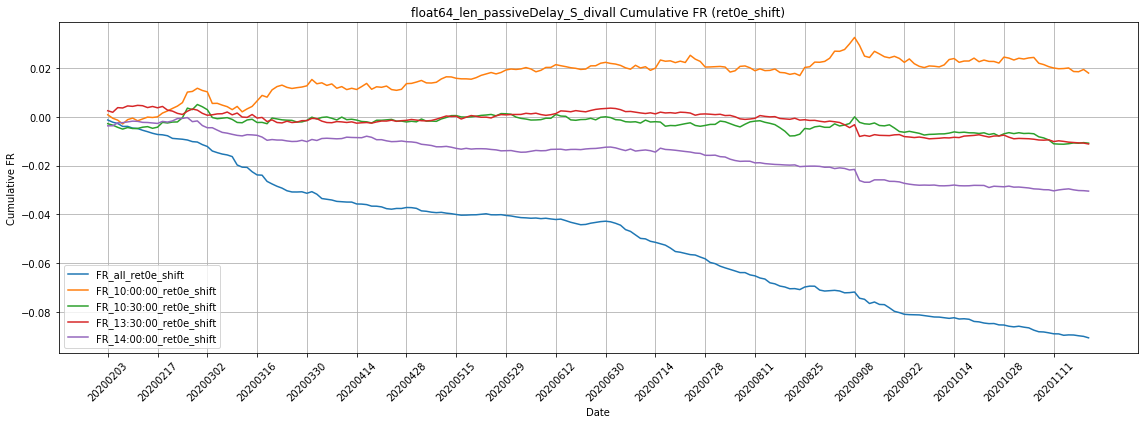

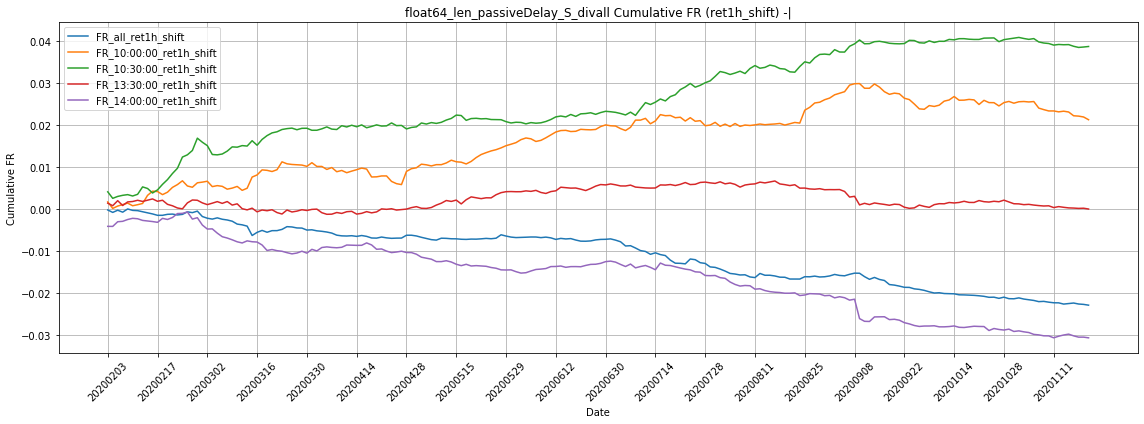

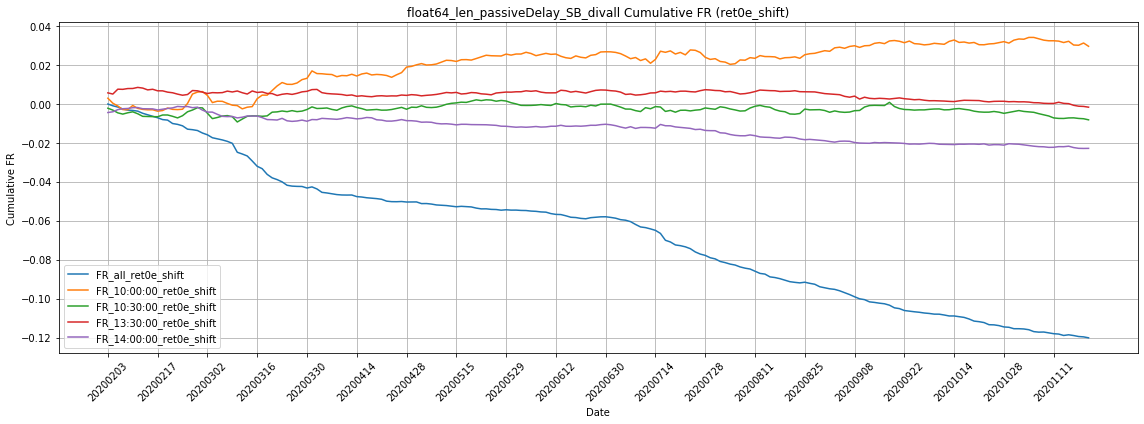

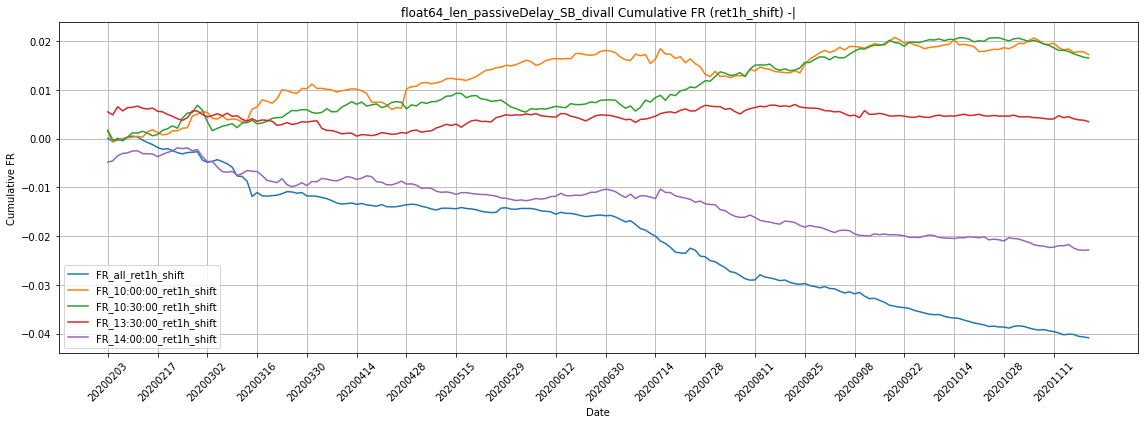

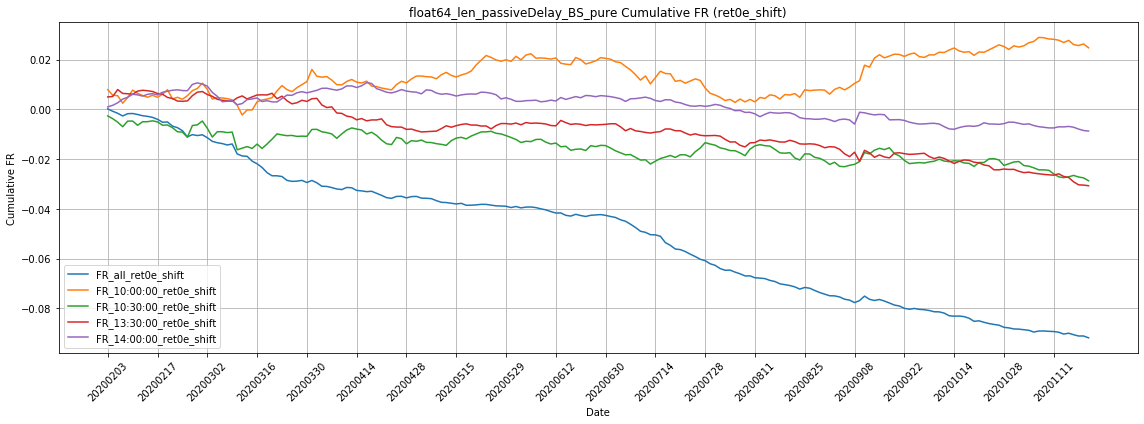

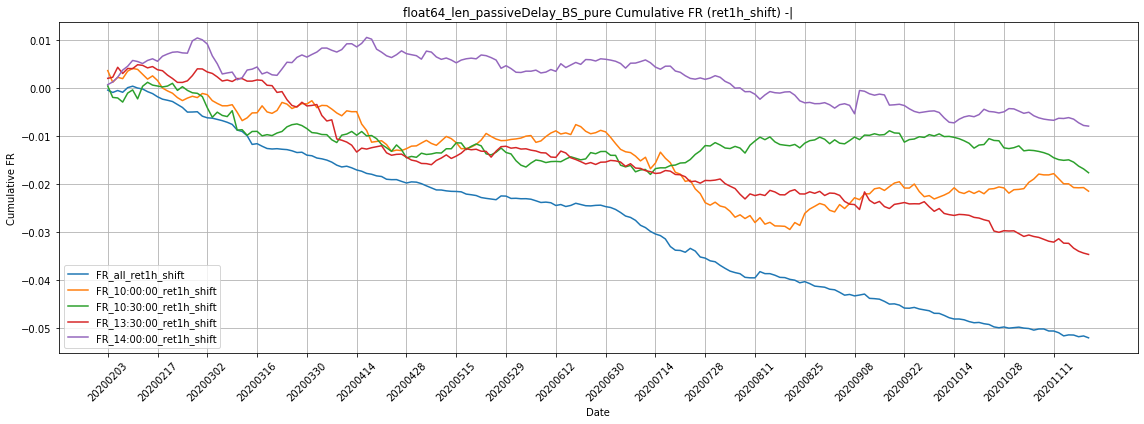

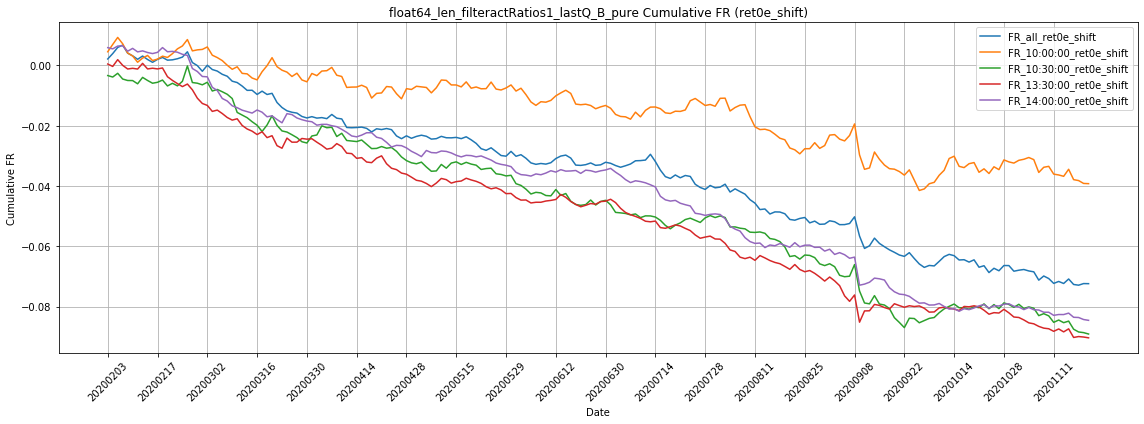

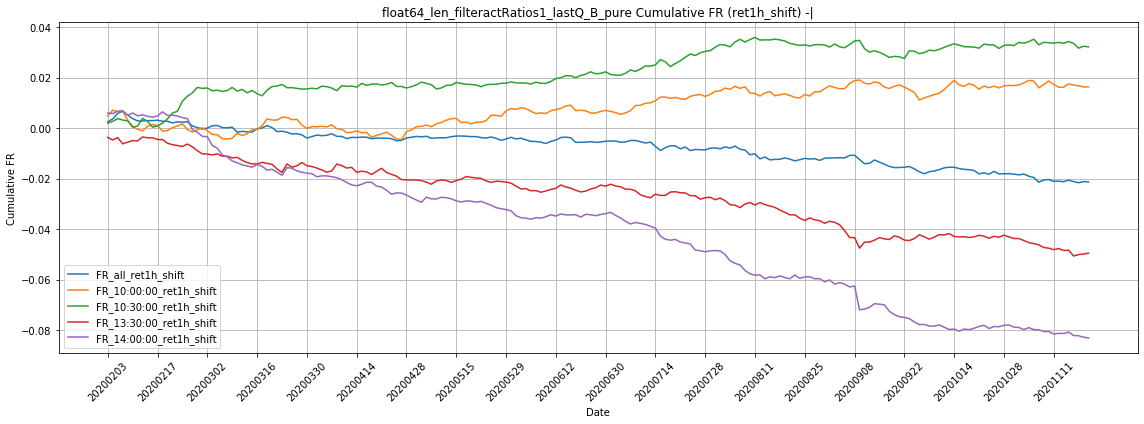

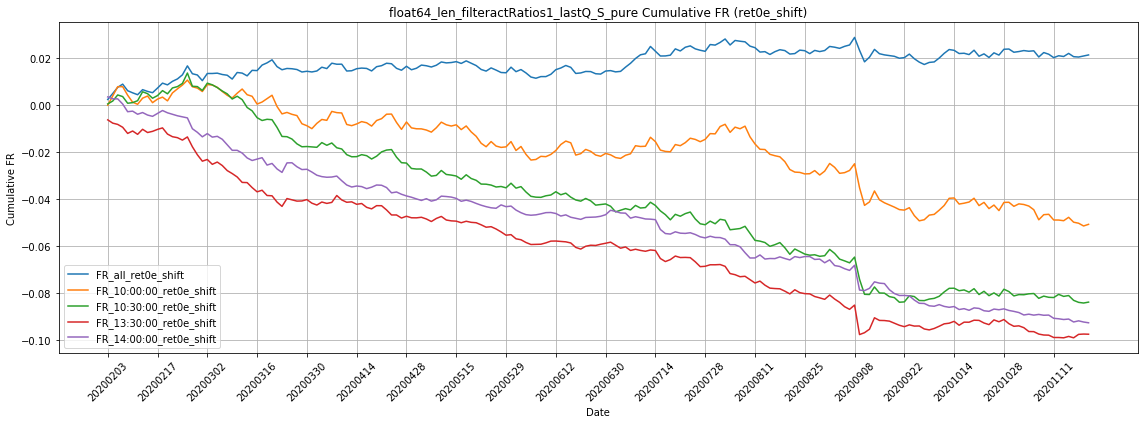

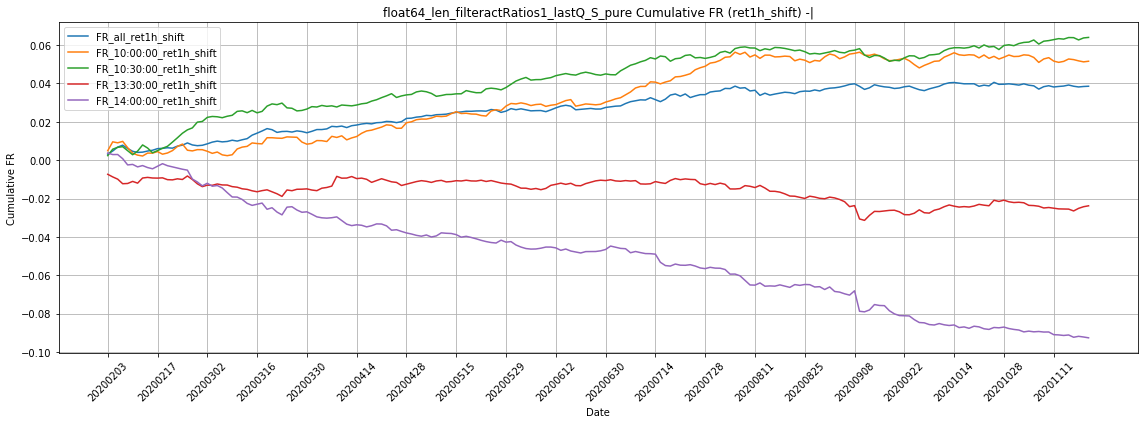

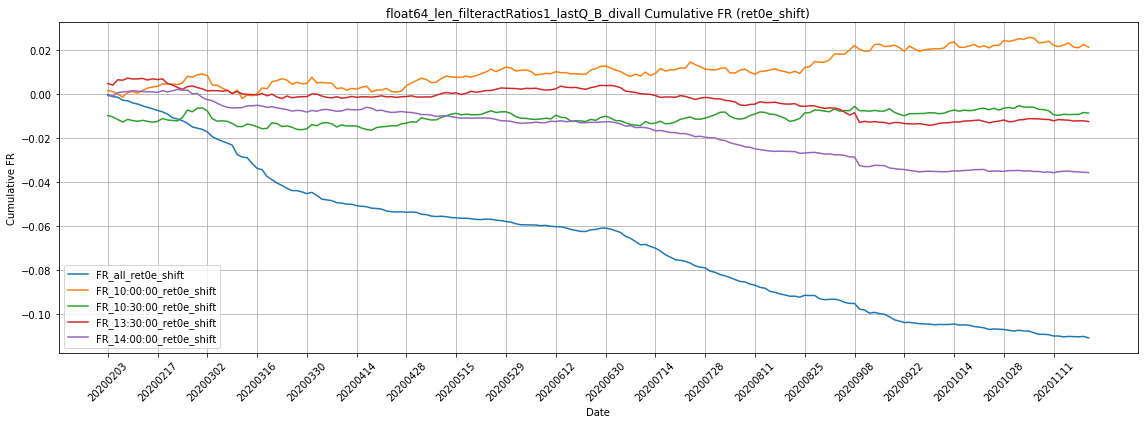

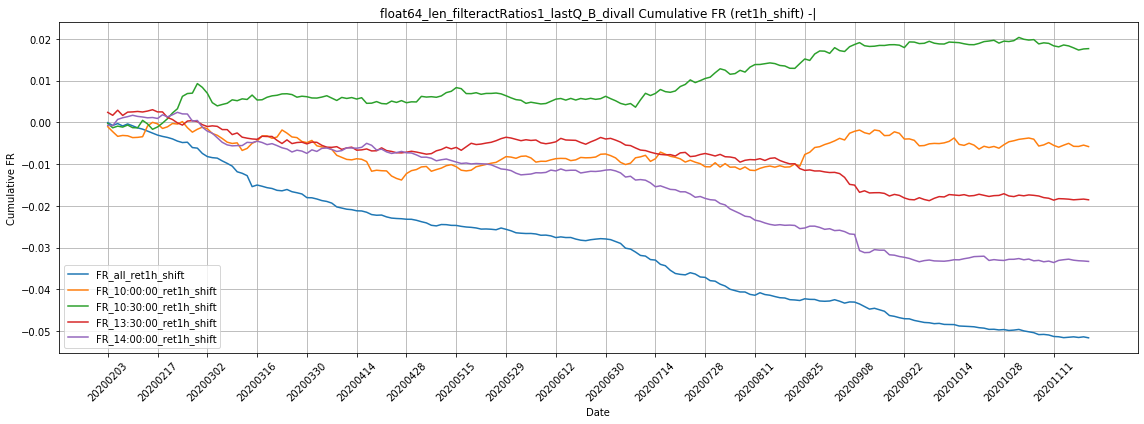

KeyError: "['float64_len_filteractRatios1_lastQ_S_divalltrd'] not in index"

In [61]:
# raise Exception('pls')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cols(feat_col):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['ret0e_shift', 'ret1h_shift']
    time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret1h_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
for feat_col in  ['float64_len_passiveDelay_SB_divall','float64_len_filteractRatios1_lastQ_B_pure','float64_len_filteractRatios1_lastQ_S_pure','float64_len_filteractRatios1_lastQ_B_divall','float64_len_filteractRatios1_lastQ_S_divalltrd','float64_len_filteractRatios1_lastQ_SB_divall','float64_len_filteractRatios1_lastQ_SB_divalltrd',
                     'Std_passiveDelay_SB_ratioavg','Mean_passiveRatio_B_divadd','float64_len_passiveDelay_SB_ratio','Sum_filteractdelayl_lastQ_SB_divall',
                 'Std_filteractdelayl_lastQ_SB_divall','Sum_filteractRatiosl_lastQ_SBratio','Sum_filterpasRatiosl_lastQ_SBratio','Std_filteractRatiosl_lastQ_SBratiosum','Std_filteractRatiosl_lastQ_SBratioavg','Std_filterpasRatiosl_lastQ_SBratiosum','Sum_filteractRatios1_lastQ_SBratio','Std_filteractRatios1_lastQ_SBratiostd','float64_len_filteractRatios1_lastQ_SBratio']:
    plot_cols(feat_col)